In [53]:
import jax
import jax.numpy as jnp
from jax import grad, value_and_grad, vmap
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (7, 4)


# Machine Learning for Physics: Supervised Learning for Simple Dynamics

In this tutorial we use a **very simple feedforward neural network** to learn trajectories of physical systems from data.

The basic supervised-learning problem is

$$
\{(t_i, x_i)\}_{i=1}^{N} \quad \longrightarrow \quad \text{learn } f_{\mathbf w}(t) \approx x(t).
$$

Today we consider two examples:

1. One charged particle in a quadratic electric potential: harmonic motion.
2. Ten charged particles near equilibrium: small coupled oscillations.

Important message: here the neural network is not given Newton's law. It only sees examples of time and position.


## A tiny neural-network toolbox

To keep the tutorial self-contained, we implement a small multilayer perceptron and a simple Adam optimizer directly in JAX.


In [54]:
def init_mlp(key, layer_sizes, scale=1.0):
    """
    Initialize a fully-connected neural network.

    Example:
        layer_sizes = [1, 32, 32, 1]
        input dimension  = 1
        output dimension = 1
        two hidden layers of width 32
    """
    keys = jax.random.split(key, len(layer_sizes) - 1)
    params = []

    for k, din, dout in zip(keys, layer_sizes[:-1], layer_sizes[1:]):
        W = scale * jax.random.normal(k, (din, dout)) / jnp.sqrt(din)
        b = jnp.zeros((dout,))
        params.append({"W": W, "b": b})

    return params


def mlp(params, x):
    """
    Forward pass of a feedforward neural network.

    Input:
        x has shape (batch_size, input_dim)

    Output:
        y has shape (batch_size, output_dim)
    """
    h = x
    for layer in params[:-1]:
        h = jnp.tanh(h @ layer["W"] + layer["b"])
    return h @ params[-1]["W"] + params[-1]["b"]


def tree_zeros_like(tree):
    return jax.tree_util.tree_map(jnp.zeros_like, tree)


def adam_update(params, grads, opt_state, step,
                lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8):
    """One Adam update for a JAX pytree of parameters."""
    m, v = opt_state

    m = jax.tree_util.tree_map(
        lambda m, g: beta1 * m + (1.0 - beta1) * g,
        m, grads
    )
    v = jax.tree_util.tree_map(
        lambda v, g: beta2 * v + (1.0 - beta2) * (g * g),
        v, grads
    )

    m_hat = jax.tree_util.tree_map(lambda m: m / (1.0 - beta1 ** step), m)
    v_hat = jax.tree_util.tree_map(lambda v: v / (1.0 - beta2 ** step), v)

    params = jax.tree_util.tree_map(
        lambda p, mh, vh: p - lr * mh / (jnp.sqrt(vh) + eps),
        params, m_hat, v_hat
    )
    return params, (m, v)


# Exercise 1: Learning a harmonic oscillator from data

Consider a charged particle in a quadratic electric potential,

$$
V(x)=\frac{1}{2}kx^2.
$$

The force is

$$
F(x)=-\frac{dV}{dx}=-kx.
$$

Newton's equation is therefore

$$
m\ddot{x}=-kx.
$$

The solution is harmonic motion,

$$
x(t)=A\cos(\omega t)+\frac{v_0}{\omega}\sin(\omega t),
\qquad
\omega=\sqrt{\frac{k}{m}}.
$$

Our machine-learning task is much simpler than solving the differential equation:

$$
t \longmapsto x(t).
$$

We generate synthetic data points $\{(t_i,x_i)\}$ and train a neural network to predict the position.

---



### A physics question: can this potential actually exist?

**Question.** We assumed a *static* quadratic electric potential $V(x,y,z)=\tfrac12 k(x^2+y^2+z^2)$. Can such a confining potential really be produced by a static electric field in free space? 


**Answer.** We can see the problem directly from Maxwell's equations.

For a static electric field, Gauss's law is

$$
\nabla\cdot \mathbf{E}=\frac{\rho}{\epsilon_0}.
$$

In electrostatics, the electric field can be written in terms of an electric potential,

$$
\mathbf{E}=-\nabla \Phi.
$$

Substituting this into Gauss's law gives

$$
\nabla\cdot(-\nabla\Phi)=\frac{\rho}{\epsilon_0},
$$

or

$$
\nabla^2\Phi=-\frac{\rho}{\epsilon_0}.
$$

This is Poisson's equation.

In free space, away from charges, we have

$$
\rho=0,
$$

so the electric potential must satisfy Laplace's equation,

$$
\nabla^2\Phi=0.
$$

Now suppose we want a stable three-dimensional harmonic trap for a charged particle. Since the potential energy is

$$
V=q\Phi,
$$

a confining harmonic potential would require the electric potential to have a local minimum, for example

$$
\Phi(x,y,z)\propto x^2+y^2+z^2.
$$

But

$$
\nabla^2(x^2+y^2+z^2)=6,
$$

so this potential does **not** satisfy Laplace's equation in free space.
Thus, a purely static electric field in free space cannot produce a stable three-dimensional quadratic confining potential for a charged particle. This is the basic idea behind Earnshaw's theorem. In this tutorial, the harmonic oscillator should be understood as an effective one-dimensional toy model.

In [55]:
# Ground-truth physics: harmonic oscillator

def oscillator_solution(t, A=1.0, v0=0.2, omega=1.5, x_eq=0.0):
    return x_eq + A * jnp.cos(omega * t) + (v0 / omega) * jnp.sin(omega * t)


# Create a synthetic dataset
key = jax.random.PRNGKey(seed=6)

T_train = 8.0      # the NN sees data only in this time window
T_plot = 14.0      # we also plot beyond the training window
n_train = 80
noise_level = 0.02

key, subkey1, subkey2 = jax.random.split(key, 3)

t_train = jnp.sort(
    jax.random.uniform(subkey1, shape=(n_train,), minval=0.0, maxval=T_train)
)
x_clean = oscillator_solution(t_train)
x_train = x_clean + noise_level * jax.random.normal(subkey2, shape=(n_train,))

t_grid = jnp.linspace(0.0, T_plot, 500)
x_grid = oscillator_solution(t_grid)


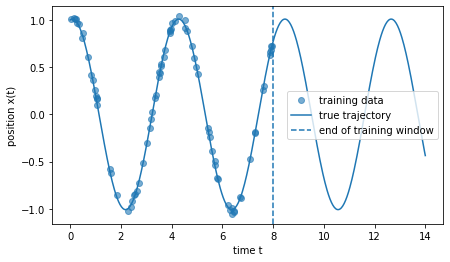

In [56]:
plt.scatter(t_train, x_train, alpha=0.6, label="training data")
plt.plot(t_grid, x_grid, label="true trajectory")
plt.axvline(T_train, linestyle="--", label="end of training window")
plt.xlabel("time t")
plt.ylabel("position x(t)")
plt.legend()
plt.show()


## Normalization

Neural networks usually train better when inputs and outputs are normalized.

We transform

$$
t \mapsto \frac{t-\mu_t}{\sigma_t},
\qquad
x \mapsto \frac{x-\mu_x}{\sigma_x}.
$$


In [57]:
# Normalization constants computed from the training data only

t_mean = t_train.mean()
t_std = t_train.std()
x_mean = x_train.mean()
x_std = x_train.std()


def t_to_input(t):
    return ((t - t_mean) / t_std).reshape(-1, 1)


def x_to_target(x):
    return ((x - x_mean) / x_std).reshape(-1, 1)


def target_to_x(y):
    return (y * x_std + x_mean).squeeze()


## Define the neural network and loss function

The model is a feedforward neural network

$$
f_{\mathbf w}(t) \approx x(t).
$$

We train it by minimizing the mean squared error,

$$
C(\mathbf w)=\frac{1}{N}\sum_{i=1}^{N}\left[f_{\mathbf w}(t_i)-x_i\right]^2.
$$


In [58]:
key, subkey = jax.random.split(key)
params = init_mlp(subkey, layer_sizes=[1, 32, 32, 1], scale=1.0)
opt_state = (tree_zeros_like(params), tree_zeros_like(params))


def mse_loss_oscillator(params, t, x):
    pred = mlp(params, t_to_input(t))
    target = x_to_target(x)
    return jnp.mean((pred - target) ** 2)


@jax.jit
def train_step_oscillator(params, opt_state, step):
    loss, grads = value_and_grad(mse_loss_oscillator)(params, t_train, x_train)
    params, opt_state = adam_update(params, grads, opt_state, step, lr=1e-3)
    return params, opt_state, loss


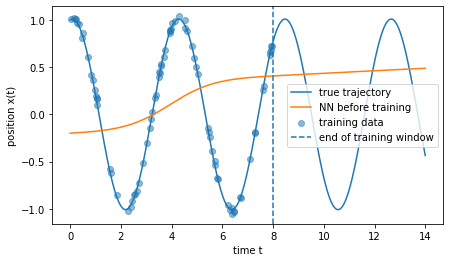

In [59]:
# Prediction before training
x_pred_before = target_to_x(mlp(params, t_to_input(t_grid)))

plt.plot(t_grid, x_grid, label="true trajectory")
plt.plot(t_grid, x_pred_before, label="NN before training")
plt.scatter(t_train, x_train, alpha=0.5, label="training data")
plt.axvline(T_train, linestyle="--", label="end of training window")
plt.xlabel("time t")
plt.ylabel("position x(t)")
plt.legend()
plt.show()


In [60]:
# Training loop

num_epochs = 2000
loss_history = []

for step in range(1, num_epochs + 1):
    params, opt_state, loss = train_step_oscillator(params, opt_state, step)
    loss_history.append(loss)

    if step % 500 == 0:
        print(f"step {step}, loss = {loss:.6f}")


step 500, loss = 0.017704
step 1000, loss = 0.001318
step 1500, loss = 0.001114
step 2000, loss = 0.001038


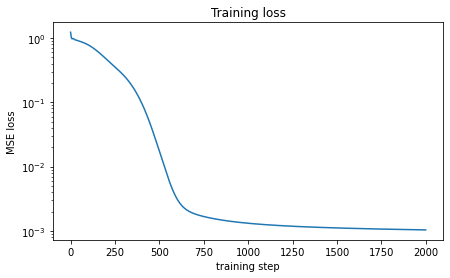

In [61]:
plt.plot(loss_history)
plt.yscale("log")
plt.xlabel("training step")
plt.ylabel("MSE loss")
plt.title("Training loss")
plt.show()


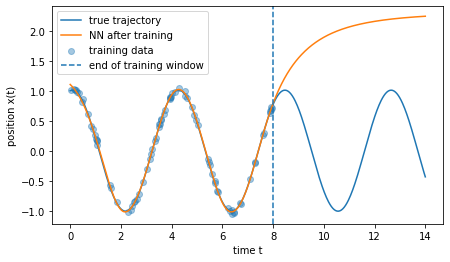

In [62]:
# Prediction after training
x_pred_after = target_to_x(mlp(params, t_to_input(t_grid)))

plt.plot(t_grid, x_grid, label="true trajectory")
plt.plot(t_grid, x_pred_after, label="NN after training")
plt.scatter(t_train, x_train, alpha=0.4, label="training data")
plt.axvline(T_train, linestyle="--", label="end of training window")
plt.xlabel("time t")
plt.ylabel("position x(t)")
plt.legend()
plt.show()


### Questions

- Does the neural network learn the trajectory well inside the training window?
- What happens outside the training window?
- Is this network learning Newton's law, or only learning one function $t\mapsto x(t)$?
- If we change the initial condition, should we expect the same network to work?


# Exercise 2: Ten charged particles near equilibrium

Now consider $N=10$ charged particles. They repel each other, and an external trapping field keeps them in place.

Near an equilibrium configuration $x_i^{(0)}$, we write

$$
x_i(t)=x_i^{(0)}+\delta x_i(t),
$$

where $\delta x_i(t)$ is small.

For small vibrations, the dynamics can be linearized:

$$
\frac{d^2}{dt^2}\delta \mathbf x(t)=-K\delta \mathbf x(t),
$$

where $K$ is an effective stiffness matrix. The eigenvectors of $K$ are the normal modes.

For this beginner tutorial, we directly build a simple Coulomb-like stiffness matrix around a set of equilibrium positions. This avoids solving a difficult nonlinear many-body problem, while keeping the main idea: **many particles have coupled oscillations**.



Normal-mode frequencies:
[0.70000005 0.71739244 0.74630797 0.77615845 0.80364347 0.8277143
 0.84808415 0.8647481  0.87779    0.88729805]


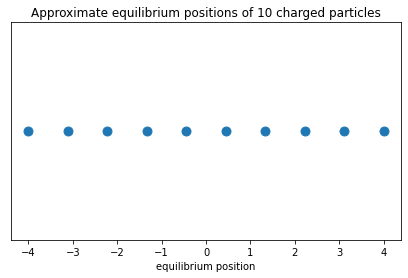

In [73]:
# Number of particles
N = 10

# Approximate equilibrium positions in a 1D trap
x_eq = jnp.linspace(-4.0, 4.0, N)

# Parameters for a simple Coulomb-like coupling matrix
omega_trap = 0.7          # external trapping strength
coulomb_strength = 0.15   # strength of inter-particle coupling
softening = 0.4           # prevents very large couplings at short distance

# Pairwise distances between equilibrium positions
r = jnp.abs(x_eq[:, None] - x_eq[None, :])

# Coulomb-like weights: particles closer to each other interact more strongly
W = coulomb_strength / (r + softening) ** 3
W = W * (1.0 - jnp.eye(N))   # remove diagonal

# Effective stiffness matrix: trap + graph Laplacian from pairwise couplings
K = omega_trap**2 * jnp.eye(N) + jnp.diag(jnp.sum(W, axis=1)) - W

# Normal modes
eigvals, eigvecs = jnp.linalg.eigh(K)
freqs = jnp.sqrt(eigvals)

print("Normal-mode frequencies:")
print(freqs)
plt.scatter(x_eq, jnp.zeros_like(x_eq), s=80)
plt.xlabel("equilibrium position")
plt.yticks([])
plt.title("Approximate equilibrium positions of 10 charged particles")
plt.show()


## Generate a many-particle trajectory

A small oscillation can be written as a sum of normal modes,

$$
\delta \mathbf x(t)
=\sum_{a=1}^{N} A_a\cos(\omega_a t+\phi_a)\mathbf v_a,
$$

where $\mathbf v_a$ is a normal-mode eigenvector.

The supervised-learning data are now

$$
(t_i,\mathbf x(t_i)),
$$

where the target is a vector containing all particle positions.


In [74]:
key, subkey1, subkey2 = jax.random.split(key, 3)

# Small random amplitudes and phases for the normal modes
amplitudes = 0.12 * jax.random.normal(subkey1, shape=(N,)) / (1.0 + jnp.arange(N))
phases = jax.random.uniform(subkey2, shape=(N,), minval=0.0, maxval=2.0 * jnp.pi)


def many_particle_trajectory(t):
    """
    Return positions of all particles at times t.

    Input:
        t has shape (n_times,)

    Output:
        x has shape (n_times, N)
    """
    q = amplitudes * jnp.cos(t[:, None] * freqs[None, :] + phases[None, :])
    displacement = q @ eigvecs.T
    return x_eq[None, :] + displacement


T_train_many = 20.0
T_plot_many = 30.0
n_train_many = 250

t_train_many = jnp.linspace(0.0, T_train_many, n_train_many)
x_train_many = many_particle_trajectory(t_train_many)

t_grid_many = jnp.linspace(0.0, T_plot_many, 500)
x_grid_many = many_particle_trajectory(t_grid_many)


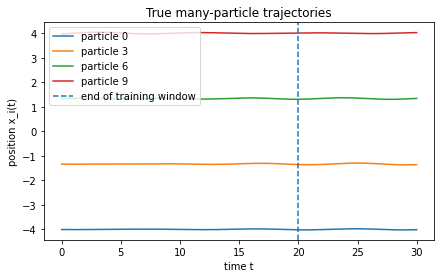

In [75]:
# Plot the trajectories of a few selected particles
for particle in [0, 3, 6, 9]:
    plt.plot(t_grid_many, x_grid_many[:, particle], label=f"particle {particle}")

plt.axvline(T_train_many, linestyle="--", label="end of training window")
plt.xlabel("time t")
plt.ylabel("position x_i(t)")
plt.title("True many-particle trajectories")
plt.legend()
plt.show()


## Neural network for vector-valued prediction

Now the input is still one number, $t$, but the output is a vector of length $N$:

$$
f_{\mathbf w}(t) \in \mathbb R^{10}.
$$

So the network learns

$$
t \longmapsto (x_1(t),x_2(t),\dots,x_{10}(t)).
$$


In [76]:
# Normalize inputs and vector-valued outputs

t_many_mean = t_train_many.mean()
t_many_std = t_train_many.std()
x_many_mean = x_train_many.mean(axis=0)
x_many_std = x_train_many.std(axis=0) + 1e-6


def t_many_to_input(t):
    return ((t - t_many_mean) / t_many_std).reshape(-1, 1)


def x_many_to_target(x):
    return (x - x_many_mean) / x_many_std


def target_to_x_many(y):
    return y * x_many_std + x_many_mean


In [77]:
key, subkey = jax.random.split(key)
params_many = init_mlp(subkey, layer_sizes=[1, 48, 48, N], scale=1.0)
opt_state_many = (tree_zeros_like(params_many), tree_zeros_like(params_many))


def mse_loss_many(params, t, x):
    pred = mlp(params, t_many_to_input(t))
    target = x_many_to_target(x)
    return jnp.mean((pred - target) ** 2)


@jax.jit
def train_step_many(params, opt_state, step):
    loss, grads = value_and_grad(mse_loss_many)(params, t_train_many, x_train_many)
    params, opt_state = adam_update(params, grads, opt_state, step, lr=1e-3)
    return params, opt_state, loss


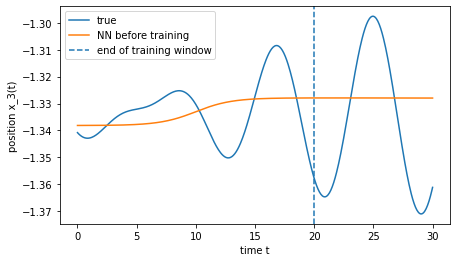

In [78]:
# Prediction before training
x_pred_many_before = target_to_x_many(
    mlp(params_many, t_many_to_input(t_grid_many))
)

particle = 3
plt.plot(t_grid_many, x_grid_many[:, particle], label="true")
plt.plot(t_grid_many, x_pred_many_before[:, particle], label="NN before training")
plt.axvline(T_train_many, linestyle="--", label="end of training window")
plt.xlabel("time t")
plt.ylabel(f"position x_{particle}(t)")
plt.legend()
plt.show()


In [79]:
# Training loop

num_epochs_many = 2000
loss_history_many = []

for step in range(1, num_epochs_many + 1):
    params_many, opt_state_many, loss = train_step_many(params_many, opt_state_many, step)
    loss_history_many.append(loss)

    if step % 500 == 0:
        print(f"step {step}, loss = {loss:.6f}")


step 500, loss = 0.024687
step 1000, loss = 0.001740
step 1500, loss = 0.000519
step 2000, loss = 0.000241


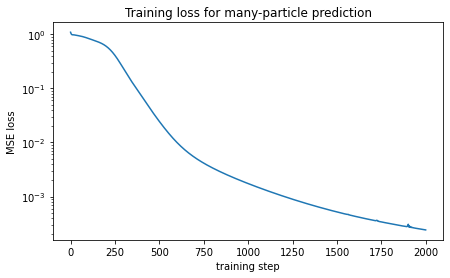

In [80]:
plt.plot(loss_history_many)
plt.yscale("log")
plt.xlabel("training step")
plt.ylabel("MSE loss")
plt.title("Training loss for many-particle prediction")
plt.show()


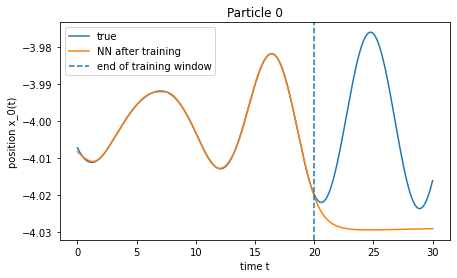

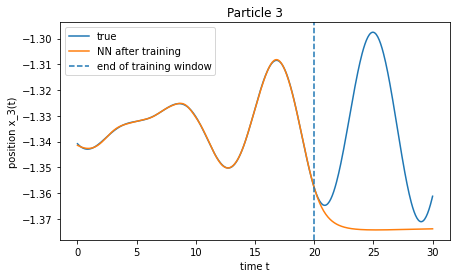

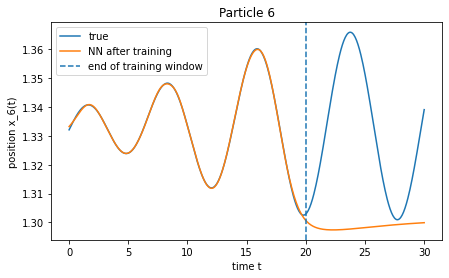

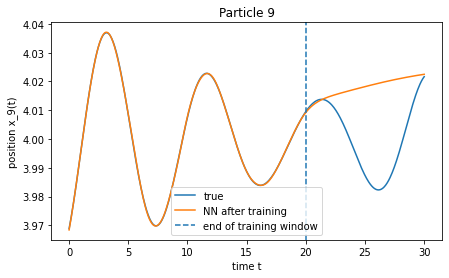

In [81]:
# Prediction after training
x_pred_many_after = target_to_x_many(
    mlp(params_many, t_many_to_input(t_grid_many))
)

for particle in [0, 3, 6, 9]:
    plt.figure(figsize=(7, 4))
    plt.plot(t_grid_many, x_grid_many[:, particle], label="true")
    plt.plot(t_grid_many, x_pred_many_after[:, particle], label="NN after training")
    plt.axvline(T_train_many, linestyle="--", label="end of training window")
    plt.xlabel("time t")
    plt.ylabel(f"position x_{particle}(t)")
    plt.title(f"Particle {particle}")
    plt.legend()
    plt.show()


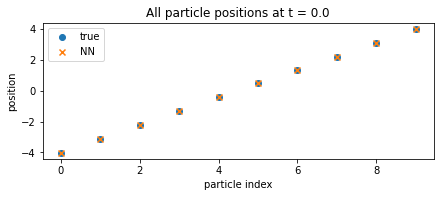

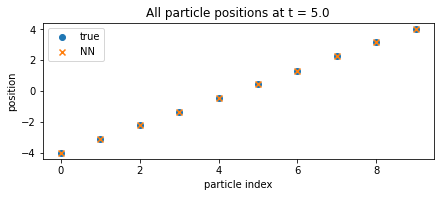

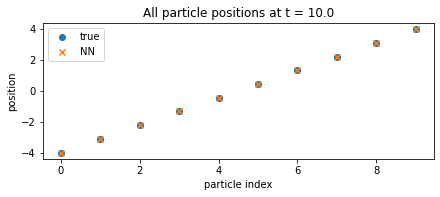

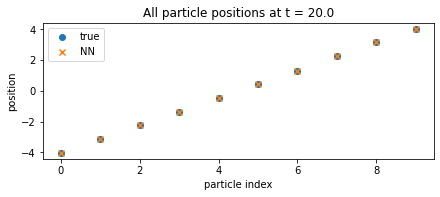

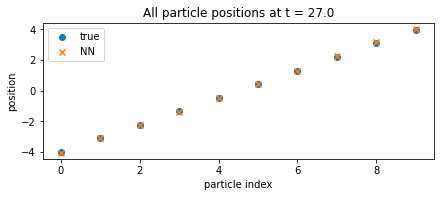

In [82]:
# Compare all particles at several times
selected_times = jnp.array([0.0, 5.0, 10.0, 20.0, 27.0])

x_true_selected = many_particle_trajectory(selected_times)
x_pred_selected = target_to_x_many(mlp(params_many, t_many_to_input(selected_times)))

for j, t in enumerate(selected_times):
    plt.figure(figsize=(7, 2.5))
    plt.scatter(np.arange(N), x_true_selected[j], label="true")
    plt.scatter(np.arange(N), x_pred_selected[j], marker="x", label="NN")
    plt.xlabel("particle index")
    plt.ylabel("position")
    plt.title(f"All particle positions at t = {float(t):.1f}")
    plt.legend()
    plt.show()


### Questions

- Why is the output dimension now 10 instead of 1?
- Why does the network usually interpolate better than it extrapolates?
- If the initial amplitudes or phases are changed, will the same function $f_{\mathbf w}(t)$ still be correct?
- What extra inputs should we give the network if we want it to predict many different initial conditions?


# Important limitation: learning a trajectory is not the same as learning dynamics

In this tutorial we trained

$$
f_{\mathbf w}: t \mapsto x(t).
$$

This is fine for a **single trajectory**.

But a real dynamical system is usually a rule such as

$$
(x(t),v(t)) \mapsto (x(t+\Delta t),v(t+\Delta t)),
$$

or a differential equation

$$
\dot{x}=F(x).
$$

So, for a more general model, one can train a neural network with inputs such as

$$
(t,x(0),v(0)) \mapsto x(t),
$$

or

$$
(x(t),v(t)) \mapsto (x(t+\Delta t),v(t+\Delta t)).
$$

This is closer to learning the physical law, not only one observed curve.


# Further exercises

- Add noise to the measured positions and see how much data is needed.
- Increase the number of particles from $N=10$ to $N=20$.
- Change the network width and depth.
- Train only on the first half-period and test on later times.
- Instead of input $t$, train a model that maps the current state to the next state.
- For the many-particle example, try to actually find the equilibrium positions by minimizing the full potential energy.
